<a href="https://colab.research.google.com/github/Patrick190508/whaleshark-mafia-island/blob/main/notebooks/Daily_EDA_Peak_Season.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Daily EDA of the peak season — Ningaloo, Philippines, Gulf of Mexico
**Patrick Silingardi · Veritas AI Fellowship · Mentor: Samuel Haghshenas**

Question: inside the peak season of each site, do daily environmental conditions (SST, chlorophyll-a, salinity) change the chance of a whale shark encounter?

Data: OBIS human sightings (cleaned, 9,731 records) + Copernicus daily series at one point per site.

Limitation stated once: sightings measure where *people* see sharks; days without sightings include days without boats at sea.

## Step 1 — Load the data

### 1.1 Sightings dataset (with sites)

In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, calendar

url = "https://raw.githubusercontent.com/Patrick190508/whaleshark-mafia-island/main/data/obis_whaleshark_clean_enriched_sites.csv"
db = pd.read_csv(url, low_memory=False)
db['date'] = pd.to_datetime(db['date'])
db['month'] = db['month'].astype(int); db['year'] = db['year'].astype(int)
db['doy'] = db['date'].dt.dayofyear
print(db.shape)
db['site'].value_counts().head(4)

(9731, 29)


,count
site,
Ningaloo Reef (W Australia),3972
Philippines,2110
Gulf of Mexico / Caribbean,978
Mozambique (Tofo / Inhambane),926


### 1.2 Daily environmental series per site (from GitHub)

In [3]:
SITES = ["Ningaloo Reef (W Australia)", "Philippines", "Mozambique (Tofo / Inhambane)"]
FILES = {SITES[0]: "daily_ningaloo.csv", SITES[1]: "daily_philippines.csv", SITES[2]: "daily_mozambique.csv"}

data_url = "https://raw.githubusercontent.com/Patrick190508/whaleshark-mafia-island/main/data/"

series = {}
for s, f in FILES.items():
    d = pd.read_csv(data_url + f, parse_dates=['date'])
    series[s] = d
    print(f"{s}: {len(d):,} days, {d['date'].min().date()} → {d['date'].max().date()} | "
          f"sst {d['sst'].notna().mean():.0%}, chl {d['chl'].notna().mean():.0%}, sss {d['sss'].notna().mean():.0%}, "
          f"sightings in series: {int(d['sightings'].sum())}\n\n")

Ningaloo Reef (W Australia): 13,405 days, 1990-01-01 → 2026-09-13 | sst 99%, chl 79%, sss 91%, sightings in series: 3971


Philippines: 13,405 days, 1990-01-01 → 2026-09-13 | sst 99%, chl 79%, sss 91%, sightings in series: 2110


Mozambique (Tofo / Inhambane): 13,405 days, 1990-01-01 → 2026-09-13 | sst 99%, chl 79%, sss 91%, sightings in series: 926




This three dataset were builded from an export from Copernicus taking a central point in each site and getting the history from 1981 to 2026 of our 3 environmental variables: SST, SSS, Chl.

## Step 2 — Peak seasons

Months chosen from the monthly table of the first EDA (≥ 10% of the site's sightings).

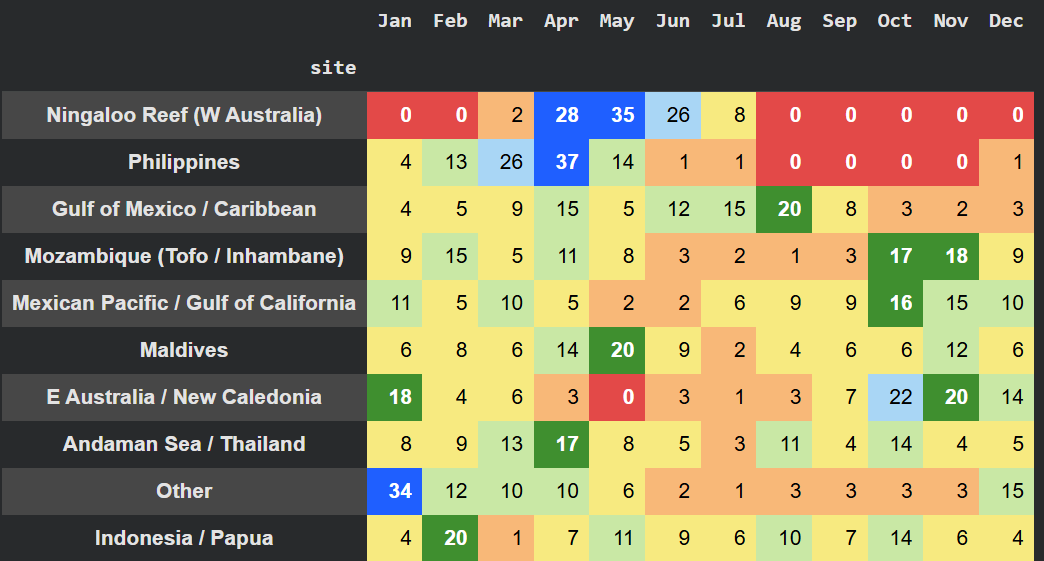

**Ningaloo Reef:** Apr-May-Jun

**Philippines:** Feb-Mar-Apr-May

**Mozambique (Tofo / Inhambane):** Oct-Nov-Dec-Jan-Feb

### 2.1 Peak months per site

In [4]:
peak_months = {
    SITES[0]: [4, 5, 6],            # Ningaloo: Apr–Jun
    SITES[1]: [2, 3, 4, 5],         # Philippines: Feb–May
    SITES[2]: [10, 11, 12, 1, 2],   # Mozambique: Oct-Feb
}
for s, m in peak_months.items():
    share = db[db['site'] == s]['month'].value_counts(normalize=True) * 100
    print(f"{s}: {[calendar.month_abbr[x] for x in m]} → {share.reindex(m).sum():.0f}% of the site's sightings\n")

Ningaloo Reef (W Australia): ['Apr', 'May', 'Jun'] → 89% of the site's sightings

Philippines: ['Feb', 'Mar', 'Apr', 'May'] → 91% of the site's sightings

Mozambique (Tofo / Inhambane): ['Oct', 'Nov', 'Dec', 'Jan', 'Feb'] → 67% of the site's sightings



**Ningaloo Reef** - 89% of sightings of the year

**Philippines** - 91% of sightings of the year

**Mozambique** - 67% of sightings of the year

***More pronounced seasonality in Ningaloo and Philippines***




In [5]:
def season_day(doy, months):
    start = pd.Timestamp(2001, months[0], 1).dayofyear
    return (doy - start) % 365 + 1

for s, m in peak_months.items():
    d = series[s]
    d['sday'] = season_day(d['doy'], m)
    d['season_year'] = np.where(d['month'] >= m[0], d['year'], d['year'] - 1) if m[0] > m[-1] else d['year']

    mask = db['site'] == s
    db.loc[mask, 'sday'] = season_day(db.loc[mask, 'doy'], m)
    db.loc[mask, 'season_year'] = np.where(db.loc[mask, 'month'] >= m[0], db.loc[mask, 'year'], db.loc[mask, 'year'] - 1) if m[0] > m[-1] else db.loc[mask, 'year']

### 2.2 Peak-season subsets

In [6]:
peak = {s: db[(db['site'] == s) & (db['month'].isin(m))].copy() for s, m in peak_months.items()}
season = {s: series[s][series[s]['month'].isin(m)].copy() for s, m in peak_months.items()}

active_years = {}
for s in SITES:
    per_year = db[db['site'] == s].groupby('year').size()
    active_years[s] = per_year[per_year >= 20].index.tolist()
    season[s] = season[s][season[s]['year'].isin(active_years[s])]
    print(f"{s}: {len(active_years[s])} active years ({min(active_years[s])}–{max(active_years[s])}) | "
          f"{len(season[s]):,} season-days, {(season[s]['sightings'] > 0).sum()} with sightings\n")

print("***----------------------------------------***\n")
for s in SITES:
    tot = len(peak[s]); kept = peak[s]['year'].isin(active_years[s]).sum()
    print(f"{s}: {kept} of {tot} season sightings kept ({kept/tot:.0%})\n")

Ningaloo Reef (W Australia): 15 active years (1995–2009) | 1,365 season-days, 808 with sightings

Philippines: 7 active years (2006–2024) | 843 season-days, 309 with sightings

Mozambique (Tofo / Inhambane): 5 active years (2005–2009) | 756 season-days, 185 with sightings

***----------------------------------------***

Ningaloo Reef (W Australia): 3464 of 3544 season sightings kept (98%)

Philippines: 1854 of 1924 season sightings kept (96%)

Mozambique (Tofo / Inhambane): 589 of 624 season sightings kept (94%)



Taking a range to wide will cause us to analyze data that cannot be correlated with sightings so i put a thresold to consider only years with **more than 20 encounters per year**

## Step 3 — Analysis tools (functions)

### 3.1 Context — annual climatology of each variable, with the season and the sightings overlaid

In [7]:
VARS = [('sst', 'SST (°C)', "#e34948"), ('chl', 'chlorophyll-a (mg/m³)', "#3f8f2f"), ('sss', 'salinity (PSU)', "#8a4fbf")]

def climatology(s, clim_from=2000):
    d = series[s][series[s]['year'] >= clim_from]; m = peak_months[s]
    full = series[s]
    daily = full[full['season_year'].isin(active_years[s])].groupby('doy')['sightings'].sum()
    ticks = [pd.Timestamp(2001, k, 1).dayofyear for k in range(1, 13)]
    labels = [calendar.month_abbr[k] for k in range(1, 13)]

    fig, axes = plt.subplots(3, 1, figsize=(12, 10))
    for ax, (var, lab, col) in zip(axes, VARS):
        q = d.groupby('doy')[var].quantile([0.25, 0.5, 0.75]).unstack()
        ax.fill_between(q.index, q[0.25], q[0.75], color=col, alpha=0.2)
        ax.plot(q.index, q[0.5], color=col, zorder=3)
        for mth in m:                                     # una fascia grigia per ogni mese di stagione
            a = pd.Timestamp(2001, mth, 1).dayofyear
            ax.axvspan(a, a + calendar.monthrange(2001, mth)[1], color="grey", alpha=0.15)
        ax.set_ylabel(lab); ax.grid(alpha=0.3)
        ax.set_xticks(ticks); ax.set_xticklabels(labels); ax.set_xlim(1, 365)
        ax2 = ax.twinx()
        ax2.bar(daily.index, daily.values, color="#2a78d6", alpha=0.35, width=1)
        ax2.set_ylabel("sightings", color="#2a78d6")

    axes[0].set_title(f"{s} — daily climatology {clim_from}–{series[s]['year'].max()} "
                      f"(median, interquartile band); grey = peak season; bars = sightings (active years)")
    plt.tight_layout(); plt.show()

### 3.2 Response curve — sightings per day for each class of the variable

In [8]:
def response_curve(s, var, bins, label):
    d = season[s].dropna(subset=[var]).copy()
    d['cls'] = pd.cut(d[var], bins=bins)
    t = d.groupby('cls', observed=True).agg(n_days=('sightings', 'size'),
                                            sightings=('sightings', 'sum'),
                                            days_with=('sightings', lambda x: (x > 0).sum()))
    t['per_day'] = (t['sightings'] / t['n_days']).round(2)
    t['p_sighting'] = (t['days_with'] / t['n_days']).round(2)

    fig, ax1 = plt.subplots(figsize=(10, 4))
    x = range(len(t))
    ax1.bar(x, t['per_day'], color="#2a78d6", alpha=0.7)
    ax1.set_ylabel("sightings per day", color="#2a78d6")
    ax1.set_xticks(list(x)); ax1.set_xticklabels([str(c) for c in t.index], rotation=30)
    for i, n in enumerate(t['n_days']): ax1.text(i, 0, f"n={n}", ha='center', va='bottom', fontsize=8, color="white")
    ax2 = ax1.twinx()
    ax2.plot(x, t['p_sighting'], color="#e34948", marker="o")
    ax2.set_ylabel("share of days with ≥1 sighting", color="#e34948"); ax2.set_ylim(0, 1)
    plt.title(f"{s} — response to {label} (peak season, active years)")
    ax1.set_xlabel(label); plt.show()
    return t

### 3.3 Anomaly response curve — same as 3.2, using the departure from the daily climatology

In [9]:
def relative_response(s, var, bins, label):
    """Avvistamenti relativi alla media della settimana, raggruppati per anomalia della variabile."""
    full = series[s]
    clim = full[full['year'] >= 2000].groupby('doy')[var].median()
    d = season[s].dropna(subset=[var]).copy()
    d['anom'] = d[var] - d['doy'].map(clim)
    d['week'] = (d['sday'] - 1) // 7
    week_mean = d.groupby(['season_year', 'week'])['sightings'].transform('mean')   # media della settimana in quell'anno
    d = d[week_mean > 0]                                                            # settimane senza nessun avvistamento non informano
    d['relative'] = d['sightings'] / week_mean[week_mean > 0]
    d['cls'] = pd.cut(d['anom'], bins=bins)
    t = d.groupby('cls', observed=True).agg(n_days=('relative', 'size'), relative=('relative', 'mean')).round(2)

    plt.figure(figsize=(9, 4))
    plt.bar(range(len(t)), t['relative'], color="#2a78d6", alpha=0.7)
    plt.axhline(1, color="grey", ls="--")
    plt.xticks(range(len(t)), [str(c) for c in t.index], rotation=30)
    for i, n in enumerate(t['n_days']): plt.text(i, 0.02, f"n={n}", ha='center', fontsize=8, color="white")
    plt.ylabel("sightings relative to the week's mean (1 = average day)")
    plt.title(f"{s} — {label} anomaly, at equal week of the season"); plt.show()
    return t

This Function works like this:



1.   For each year from 2000 onwards it calculates the temperature of each day and save the median for each day. (example 1 jan 2000 25°C, 1 jan 2001 26.5°C... From all this values we take the median and use it as the Standard Value for 1st of January)
2.   Then it goes through each day and calculate the anomaly of that day ex.(std value of 1st of January = 26°C. Value of 1st of January 2026 = 27°C. Anomaly for 1/01/2026 = +1) At the end we have each day mapped with this anomaly
3.   For each day we create a value that tell us in this day we saw more or less whaleshark compared to the other days of the weak ex. (in the week 1/01/2026 - 8/01/2026 we have a mean of 6 encounters each day. But the 1st we had 9 so more encounters than the mean of the week values = 9/6 = 1.33)
4.   It creates a plot that shows if sightings with anomaly are more correlated with a change of the probability to encounter a shark. (if our example was real for the majority of the day we would see that the +1 anomaly had a value of sighting greater than 1 which mean more shark are seen in days that are hotter than usual)



### 3.4 Lagged chlorophyll — response curve with chlorophyll of 2, 4, 6 weeks before

In [10]:
LAGS = [0, 14, 28, 42]
CHL_CLASSES = [0, 0.2, 0.3, 0.4, 0.5, 1]

def add_lagged(s, var='chl'):
    """Aggiunge a series[s] la variabile di L giorni prima e aggiorna season[s]."""
    full = series[s].sort_values('date').reset_index(drop=True)
    for L in LAGS:
        full[f'{var}_lag{L}'] = full[var].shift(L)
    series[s] = full
    season[s] = full[full['month'].isin(peak_months[s]) & full['season_year'].isin(active_years[s])].copy()

def lagged_response(s, var='chl', bins=CHL_CLASSES, label='chlorophyll-a (mg/m³)'):
    """Un pannello per ogni ritardo: avvistamenti per giorno in funzione della variabile di L giorni prima."""
    if f'{var}_lag{LAGS[-1]}' not in series[s].columns:
        add_lagged(s, var)
    fig, axes = plt.subplots(1, len(LAGS), figsize=(4 * len(LAGS), 4), sharey=True)
    for ax, L in zip(axes, LAGS):
        col = f'{var}_lag{L}'
        d = season[s].dropna(subset=[col]).copy()
        d['cls'] = pd.cut(d[col], bins=bins)
        t = d.groupby('cls', observed=True).agg(n_days=('sightings', 'size'), sightings=('sightings', 'sum'),
                                                days_with=('sightings', lambda x: (x > 0).sum()))
        t['per_day'] = t['sightings'] / t['n_days']; t['p_sighting'] = t['days_with'] / t['n_days']
        x = range(len(t))
        ax.bar(x, t['per_day'], color="#3f8f2f", alpha=0.7)
        ax.set_xticks(list(x)); ax.set_xticklabels([str(c) for c in t.index], rotation=45, fontsize=8)
        for i, n in enumerate(t['n_days']): ax.text(i, 0.05, f"n={n}", ha='center', fontsize=7, color="white")
        ax2 = ax.twinx(); ax2.plot(x, t['p_sighting'], color="#e34948", marker="o"); ax2.set_ylim(0, 1)
        if L != LAGS[-1]: ax2.set_yticklabels([])
        ax.set_title(f"{label} {L} days before")
    axes[0].set_ylabel("sightings per day"); ax2.set_ylabel("share of days with ≥1 sighting", color="#e34948")
    plt.suptitle(f"{s} — response to chlorophyll-a of 0/14/28/42 days before (peak season, active years)")
    plt.tight_layout(); plt.show()

### 3.5 Year by year — season mean conditions vs timing and size of the peak

In [11]:
def season_by_year(s):
    d = season[s]
    rows = []
    for y, g in d.groupby('season_year'):
        n = g['sightings'].sum()
        if n < 20: continue
        w = g.set_index('sday')['sightings'].rolling(7, center=True, min_periods=1).sum()
        rows.append({'season': int(y), 'sightings': int(n), 'peak_sday': int(w.idxmax()),
                     'sst': g['sst'].mean(), 'chl': g['chl'].mean(), 'sss': g['sss'].mean()})
    return pd.DataFrame(rows).round(2)

def year_plots(s):
    t = season_by_year(s)
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    for j, (var, lab, col) in enumerate(VARS):
        for i, (y, ylab) in enumerate([('peak_sday', 'day of season of the peak'), ('sightings', 'sightings in the season')]):
            ax = axes[i, j]
            ax.scatter(t[var], t[y], color=col)
            for _, r in t.iterrows(): ax.annotate(int(r['season']), (r[var], r[y]), fontsize=7, alpha=0.7)
            ax.set_xlabel(f"season mean {lab}"); ax.set_ylabel(ylab); ax.grid(alpha=0.3)
            ax.set_title(f"r = {t[var].corr(t[y]):.2f}", fontsize=10)
    plt.suptitle(f"{s} — season by season ({len(t)} seasons with ≥ 20 sightings)"); plt.tight_layout(); plt.show()
    return t

## Step 4 — Results per site

### 4.1 Ningaloo Reef (W Australia) — April to June

#### Context (climatology)

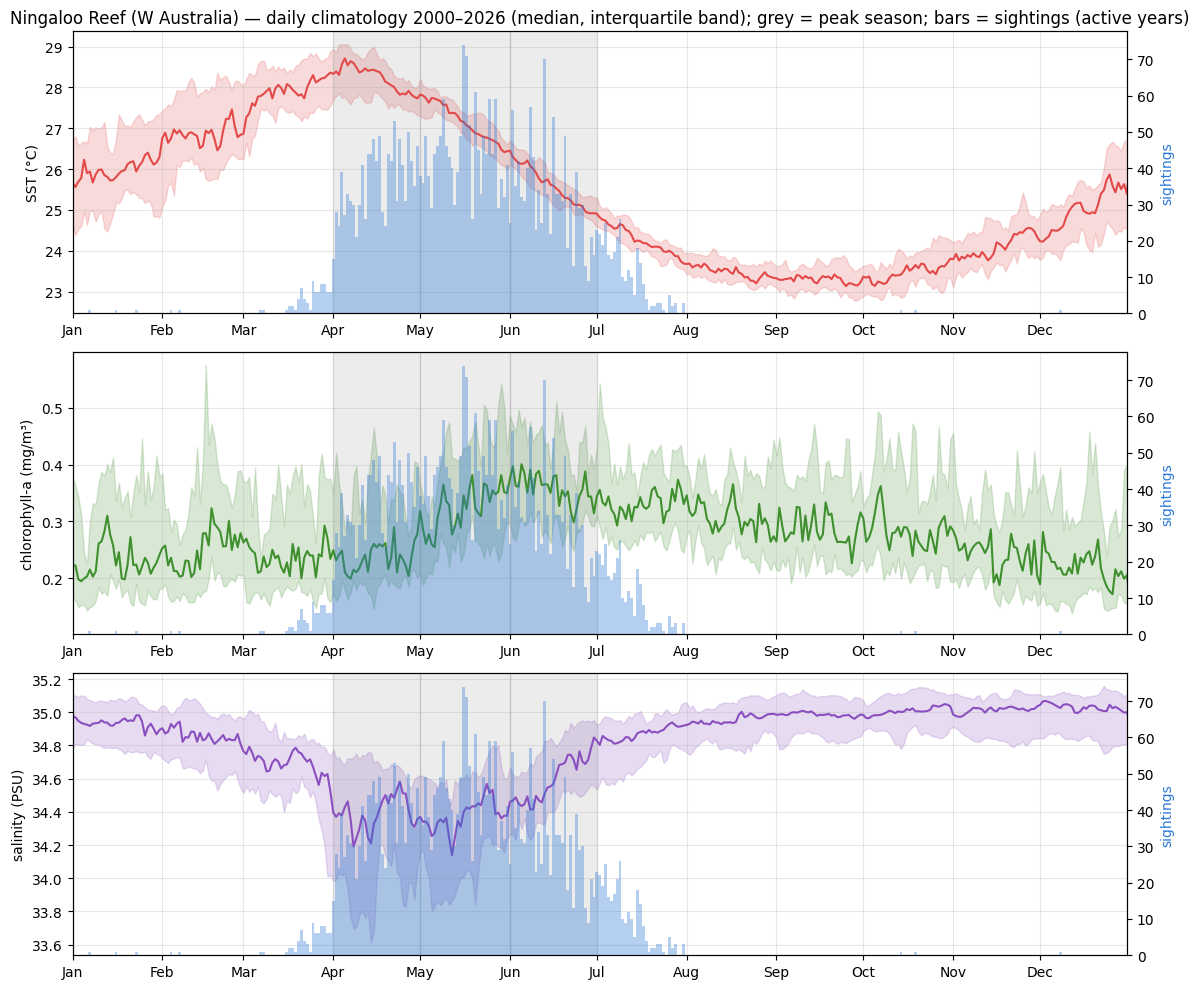

,chl
month,
1,0.22
2,0.25
3,0.23
4,0.24
5,0.32
6,0.36
7,0.33
8,0.30
9,0.29


In [12]:
climatology(SITES[0])
d = series[SITES[0]]; d = d[d['year'] >= 2000]
d.groupby('month')['chl'].median().round(2)

*Reading:*

**SST:** The **season is overlapping with the decrease** of the SST from 28°C to 24.5°C.

**Chlorophyll-a:** The table of monthly medians shows a weak seasonal pattern: values are flat at 0.22–0.25 mg/m³ from November to April, rise from the start of the season (0.24 in April) to a peak at its end (0.36 in June), then decline slowly until November. The increase happens inside the season and peaks when sightings are already falling: at Ningaloo the **sharks arrive before the chlorophyll rise, not after it.**

**SSS:** The pattern is strong we see a **clear drop in salinity values correlated with the high season**.

#### Response curves — SST

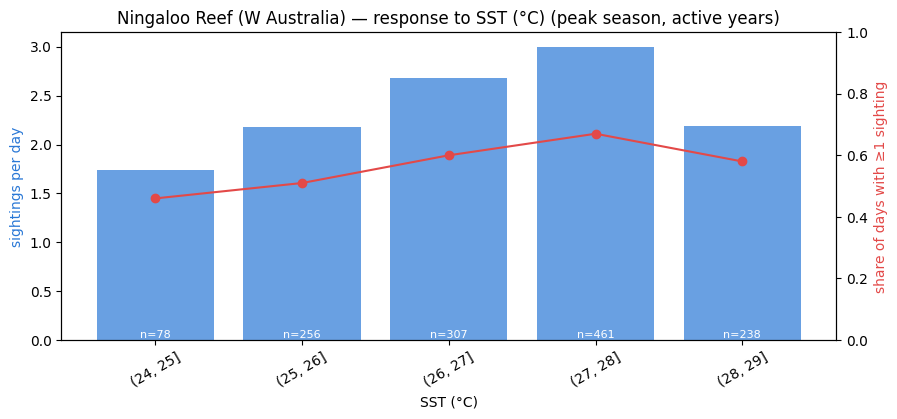

,n_days,sightings,days_with,per_day,p_sighting
cls,,,,,
"(24, 25]",78,136,36,1.74,0.46
"(25, 26]",256,557,130,2.18,0.51
"(26, 27]",307,823,185,2.68,0.60
"(27, 28]",461,1381,308,3.00,0.67
"(28, 29]",238,522,137,2.19,0.58


In [13]:
s = SITES[0]
response_curve(s, 'sst', [24, 25, 26, 27, 28, 29], 'SST (°C)')

*Reading:* Clear bell-shaped response. Sightings per day rise from 1.7 at 24–25 °C to a maximum of 3.0 at 27–28 °C and fall back to 2.2 above 28 °C; the share of days with at least one sighting follows the same shape (46% → 68% → 59%). All classes have more than 78 days, so the curve is reliable. The effect is moderate (×1.8 between the worst and the best class): temperature matters within the season, but sharks are still seen on almost half of the coldest days. Since the cold classes are also the late-season weeks, the anomaly curve (3.3) checks whether the shape holds at equal date.

#### Response curves — chlorophyll-a

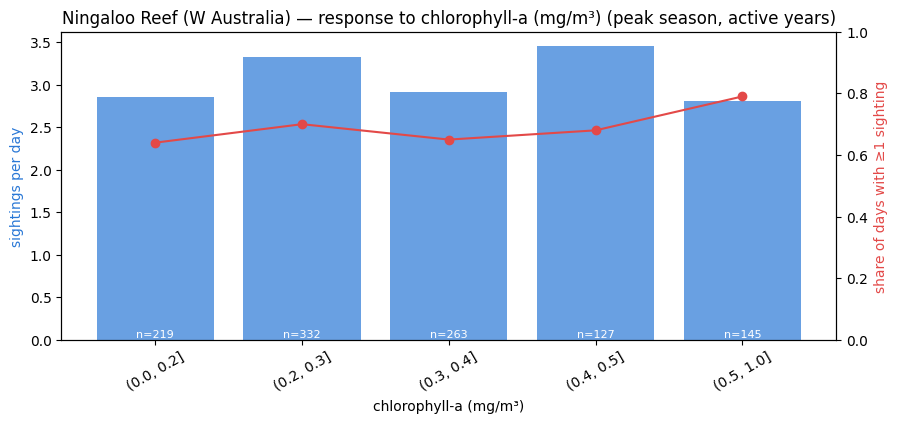

,n_days,sightings,days_with,per_day,p_sighting
cls,,,,,
"(0.0, 0.2]",219,624,141,2.85,0.64
"(0.2, 0.3]",332,1104,233,3.33,0.70
"(0.3, 0.4]",263,768,170,2.92,0.65
"(0.4, 0.5]",127,438,86,3.45,0.68
"(0.5, 1.0]",145,407,114,2.81,0.79


In [14]:
response_curve(SITES[0], 'chl', [0, 0.2, 0.3, 0.4, 0.5, 1], 'chlorophyll-a (mg/m³)')

*Reading:* Flat. Sightings per day vary between 2.8 and 3.5 across the chlorophyll classes with no ordered pattern, and the share of days with a sighting stays between 63% and 79%. Same-day chlorophyll-a does not change the chance of an encounter at Ningaloo, consistent with the climatology (the seasonal rise happens regardless of the sharks) and with the literature (aggregations follow prey patches that a 4 km satellite product cannot see). A lagged effect is tested in 3.4.

#### Response curves — salinity

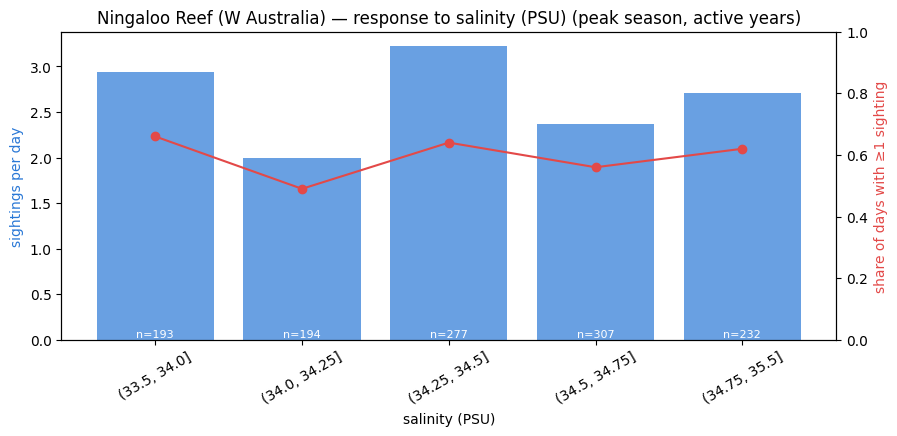

,n_days,sightings,days_with,per_day,p_sighting
cls,,,,,
"(33.5, 34.0]",193,567,127,2.94,0.66
"(34.0, 34.25]",194,387,96,1.99,0.49
"(34.25, 34.5]",277,891,178,3.22,0.64
"(34.5, 34.75]",307,728,173,2.37,0.56
"(34.75, 35.5]",232,629,143,2.71,0.62


In [15]:
response_curve(SITES[0], 'sss', [33.5, 34.0, 34.25, 34.5, 34.75, 35.5], 'salinity (PSU)')

*Reading:* No pattern. Sightings per day move up and down across the salinity classes (2.9, 2.0, 3.2, 2.4, 2.7) with no ordered trend, and the share of days with a sighting stays between 50% and 67%. Salinity marks the season (annual minimum, see climatology) but does not change the chance of an encounter from one day to the next.

#### Anomaly response curves

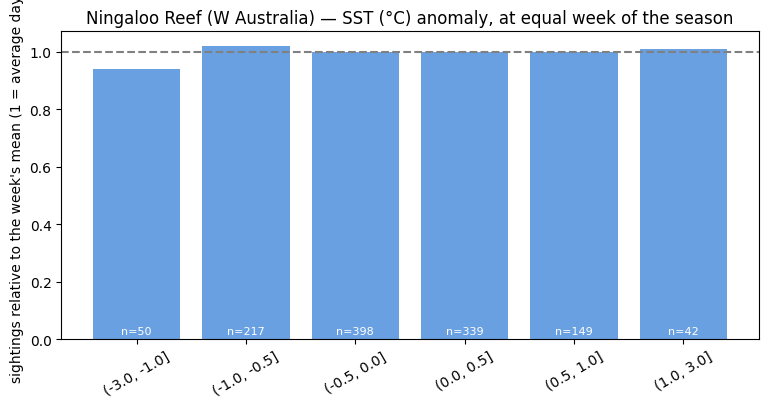

,n_days,relative
cls,,
"(-3.0, -1.0]",50,0.94
"(-1.0, -0.5]",217,1.02
"(-0.5, 0.0]",398,1.00
"(0.0, 0.5]",339,1.00
"(0.5, 1.0]",149,1.00
"(1.0, 3.0]",42,1.01


In [16]:
relative_response(SITES[0], 'sst', [-3, -1, -0.5, 0, 0.5, 1, 3], 'SST (°C)')

*Reading:* From the graph we can see that an high SST is not related with a higher chance of encountering a whale shark but the pattern we saw in point the Response Curve SST was just an effect from the high-season period's SST
(In april we have more encounters and the temperature is high but in days of june where the temperature were higher (similar values of april) there was not an increase in sightings number than it usually is)

#### Lagged chlorophyll

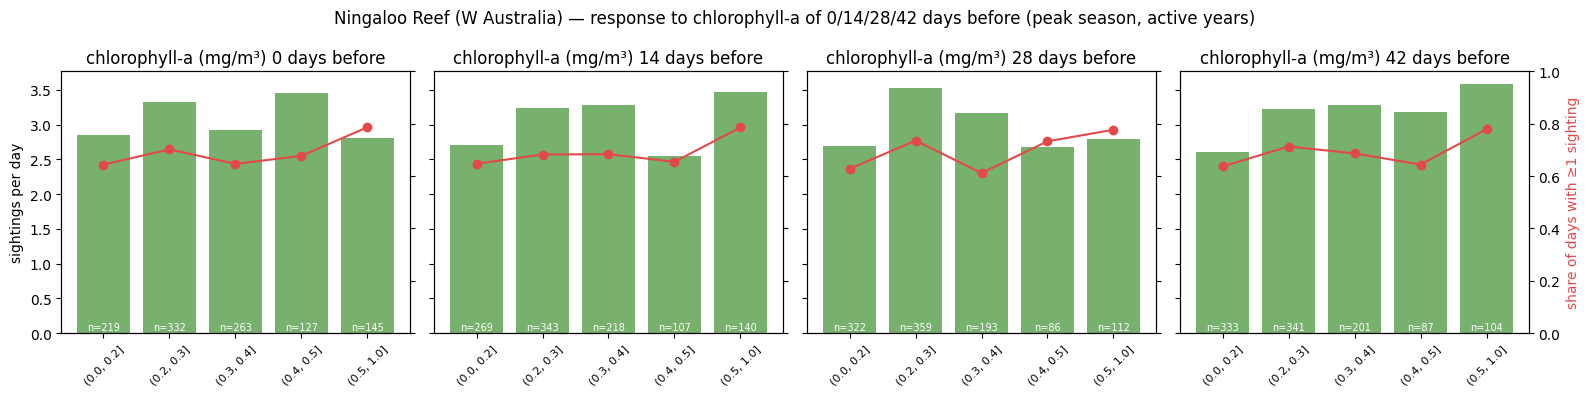

In [17]:
lagged_response(SITES[0])

*Reading:* No cleared lagged correlations between chlorophyl and sightings.

#### Year by year

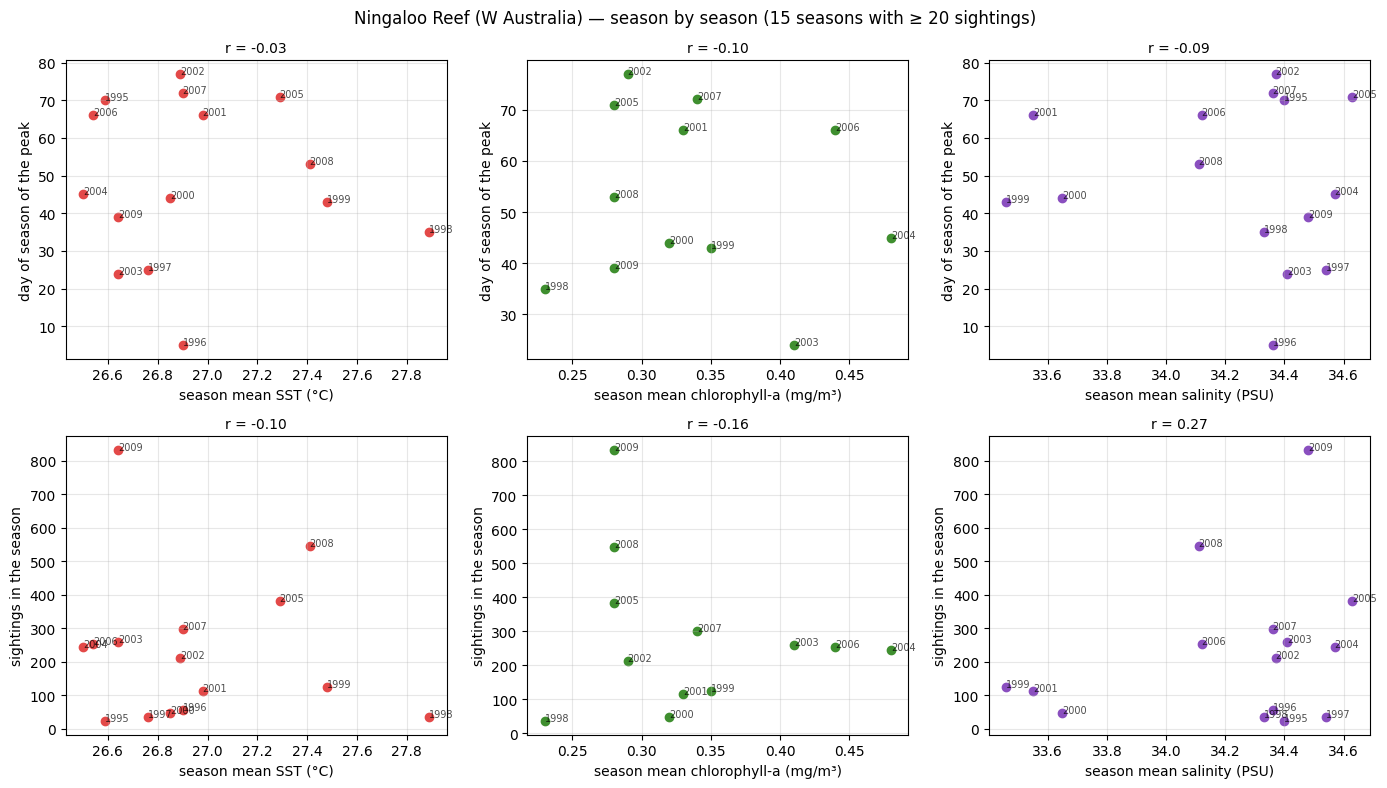

,season,sightings,peak_sday,sst,chl,sss
0,1995,23,70,26.59,NaN,34.40
1,1996,56,5,26.90,NaN,34.36
2,1997,35,25,26.76,NaN,34.54
3,1998,35,35,27.89,0.23,34.33
4,1999,125,43,27.48,0.35,33.46
5,2000,48,44,26.85,0.32,33.65
6,2001,114,66,26.98,0.33,33.55
7,2002,211,77,26.89,0.29,34.37
8,2003,259,24,26.64,0.41,34.41
9,2004,245,45,26.50,0.48,34.57


In [18]:
year_plots(s)

*Reading:* There are no relevant correlation between the sightings in a season and the environmental variables examined

### 4.2 Philippines — February to May

#### Context (climatology)

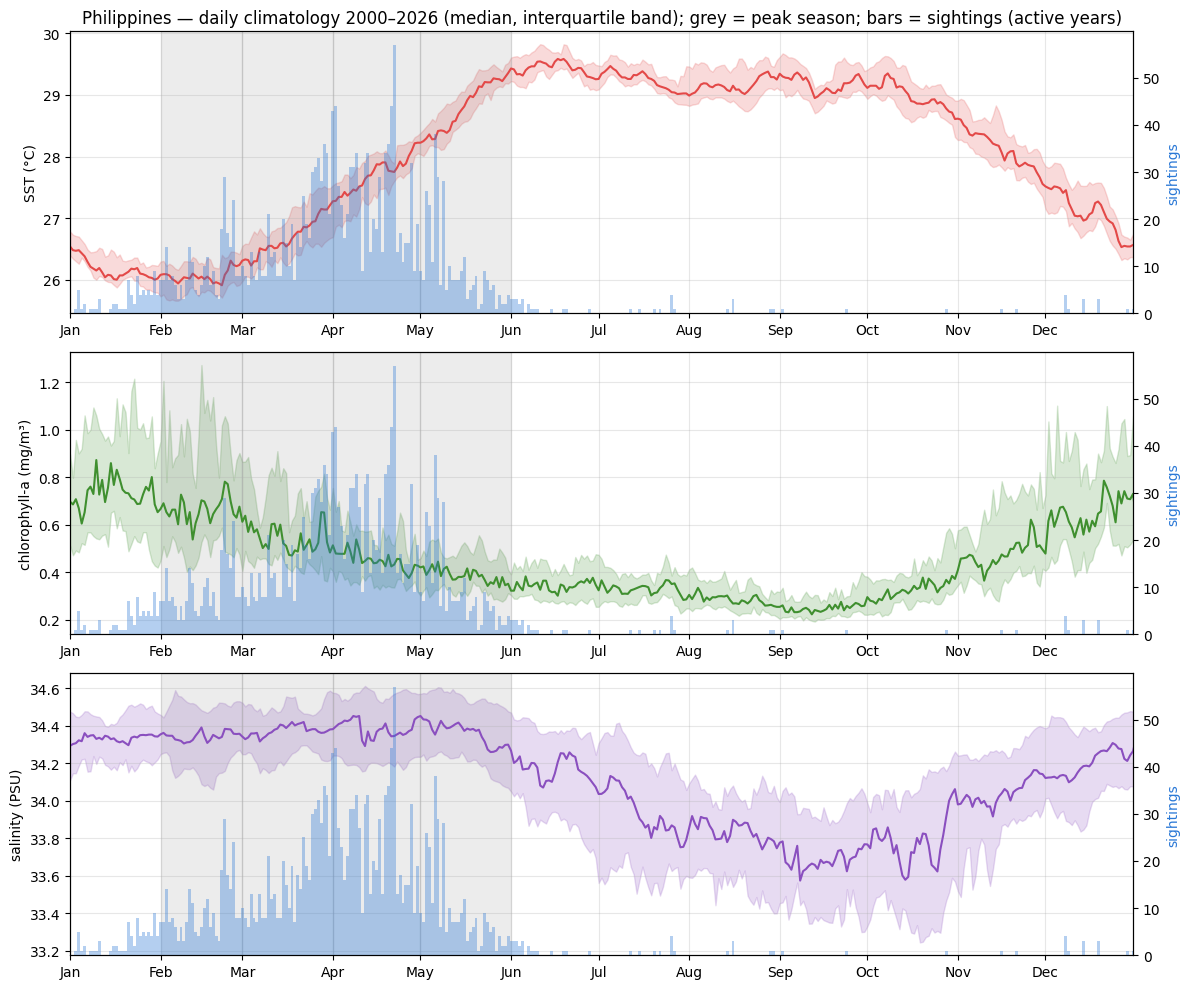

In [19]:
s = SITES[1]
climatology(s)

*Reading:*

**SST:** Here we tend to see the opposite of what we saw in Ningaloo. Shark are seen when the SST is rising with the season starting in February at 26°C and ening in May at 29°C

**Chlorophyll-a:** The trend is weak but we see that the value through the season tend to drop and then they come back up just before the season starts in november/december

**SSS:** High and stable (34.3–34.4 PSU) during the season, dropping to 33.6–33.8 in July–October with the monsoon rains. Within the season the variation is tiny, so no daily effect is expected. Note that the season coincides with the annual salinity maximum here and with the annual minimum at Ningaloo, so the absolute value of salinity is not what matters.

#### Response curves — SST

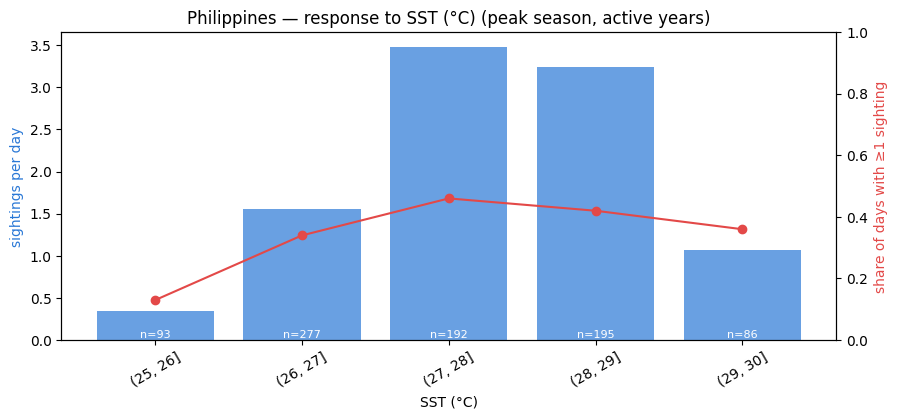

,n_days,sightings,days_with,per_day,p_sighting
cls,,,,,
"(25, 26]",93,33,12,0.35,0.13
"(26, 27]",277,428,95,1.55,0.34
"(27, 28]",192,669,89,3.48,0.46
"(28, 29]",195,632,82,3.24,0.42
"(29, 30]",86,92,31,1.07,0.36


In [20]:
response_curve(s, 'sst', [25, 26, 27, 28, 29, 30], 'SST (°C)')

*Reading:* Strong bell shape: sightings per day rise from 0.3 at 25–26 °C to 3.5 at 27–28 °C and fall to 1.1 above 29 °C (a factor of 10; share of days with a sighting from 13% to 47%). All classes have more than 86 days.

#### Response curves — chlorophyll-a

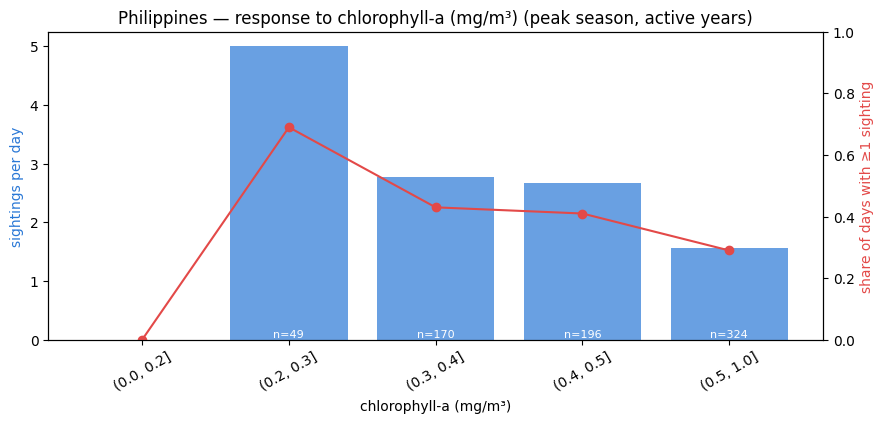

,n_days,sightings,days_with,per_day,p_sighting
cls,,,,,
"(0.0, 0.2]",1,0,0,0.00,0.00
"(0.2, 0.3]",49,245,34,5.00,0.69
"(0.3, 0.4]",170,473,73,2.78,0.43
"(0.4, 0.5]",196,524,80,2.67,0.41
"(0.5, 1.0]",324,509,95,1.57,0.29


In [21]:
response_curve(s, 'chl', [0, 0.2, 0.3, 0.4, 0.5, 1], 'chlorophyll-a (mg/m³)')

*Reading:* Sightings decrease as chlorophyll increases (5.0 → 1.6 per day). But chlorophyll falls through the season, so high values = February (few sharks) and low values = April (peak). Probably the calendar, checked below.

#### Response curves — salinity

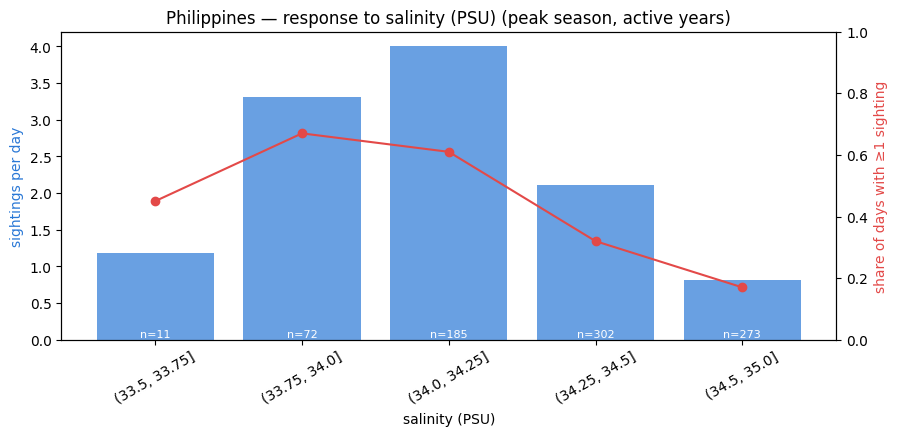

,n_days,sightings,days_with,per_day,p_sighting
cls,,,,,
"(33.5, 33.75]",11,13,5,1.18,0.45
"(33.75, 34.0]",72,238,48,3.31,0.67
"(34.0, 34.25]",185,740,113,4.00,0.61
"(34.25, 34.5]",302,638,97,2.11,0.32
"(34.5, 35.0]",273,225,46,0.82,0.17


In [22]:
response_curve(s, 'sss', [33.5, 33.75, 34.0, 34.25, 34.5, 35.0], 'salinity (PSU)')

*Reading:* *Reading:* Bell shape: most sightings at 34.0–34.25 PSU (4.0 per day), very few above 34.5 (0.8 per day). Salinity barely changes within the season, so this likely comes from differences between years. Checked below and in 3.5.

#### Anomaly response curves

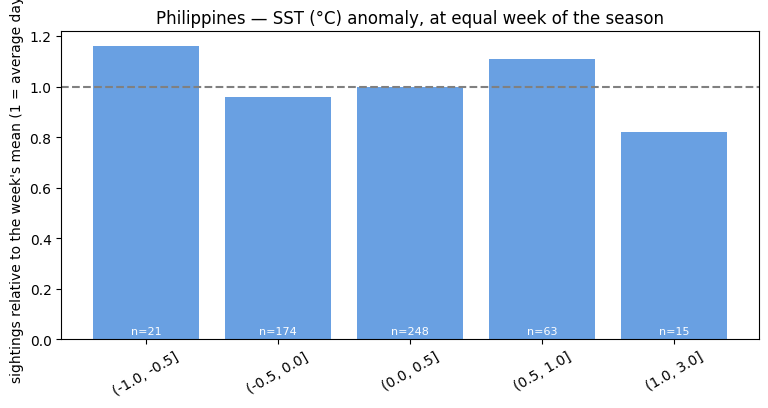

,n_days,relative
cls,,
"(-1.0, -0.5]",21,1.16
"(-0.5, 0.0]",174,0.96
"(0.0, 0.5]",248,1.00
"(0.5, 1.0]",63,1.11
"(1.0, 3.0]",15,0.82


In [23]:
relative_response(s, 'sst', [-3, -1, -0.5, 0, 0.5, 1, 3], 'SST (°C)')


*Reading:* The SST pattern disappears at equal week: the two central classes, which hold most days (174 and 248), sit at 0.96 and 1.00; the three other classes have only 15–63 days and scatter without order. The bell shape was the calendar: 25–26 °C is February (season start), 27–28 °C is late March–April (peak), above 29 °C is May (season end). As at Ningaloo, temperature describes the season but not the day. The peak falls at 27–28 °C in both sites, on the warming limb here and on the cooling limb at Ningaloo — a coincidence of mid-season temperatures rather than evidence of a thermal preference.

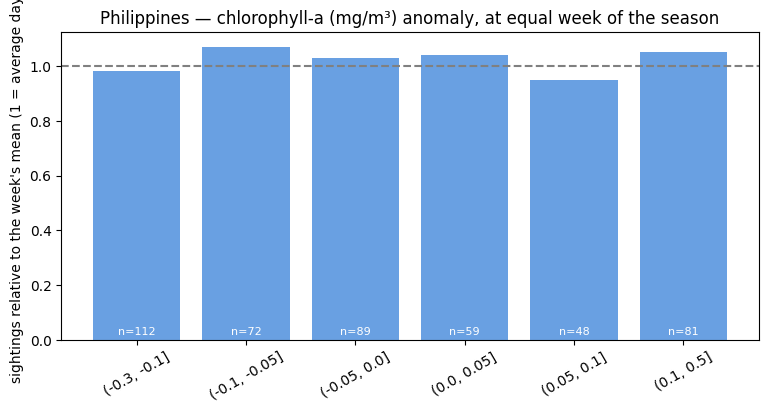

,n_days,relative
cls,,
"(-0.3, -0.1]",112,0.98
"(-0.1, -0.05]",72,1.07
"(-0.05, 0.0]",89,1.03
"(0.0, 0.05]",59,1.04
"(0.05, 0.1]",48,0.95
"(0.1, 0.5]",81,1.05


In [24]:
relative_response(s, 'chl', [-0.3, -0.1, -0.05, 0, 0.05, 0.1, 0.5], 'chlorophyll-a (mg/m³)')


*Reading:* Flat (0.95–1.07). The decreasing curve above was the calendar. Same-day chlorophyll has no effect.

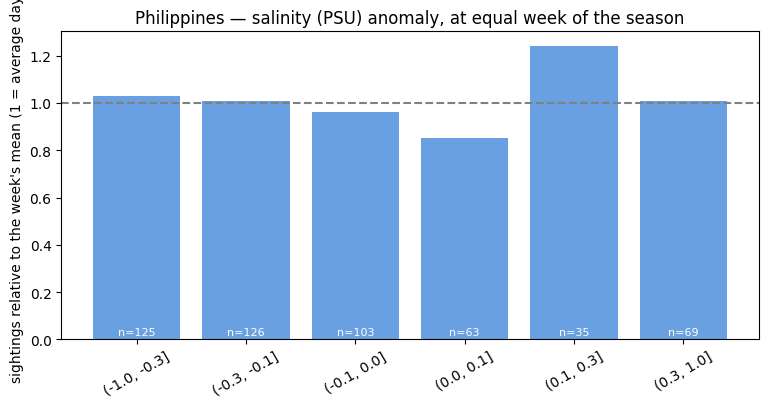

,n_days,relative
cls,,
"(-1.0, -0.3]",125,1.03
"(-0.3, -0.1]",126,1.01
"(-0.1, 0.0]",103,0.96
"(0.0, 0.1]",63,0.85
"(0.1, 0.3]",35,1.24
"(0.3, 1.0]",69,1.01


In [25]:
relative_response(s, 'sss', [-1, -0.3, -0.1, 0, 0.1, 0.3, 1], 'salinity (PSU)')

*Reading:* Flat in the populated classes (0.85–1.03); the one high bar has only 35 days. No day-to-day effect. The contrast in the response curve comes from differences between years, see 3.5.

#### Lagged chlorophyll

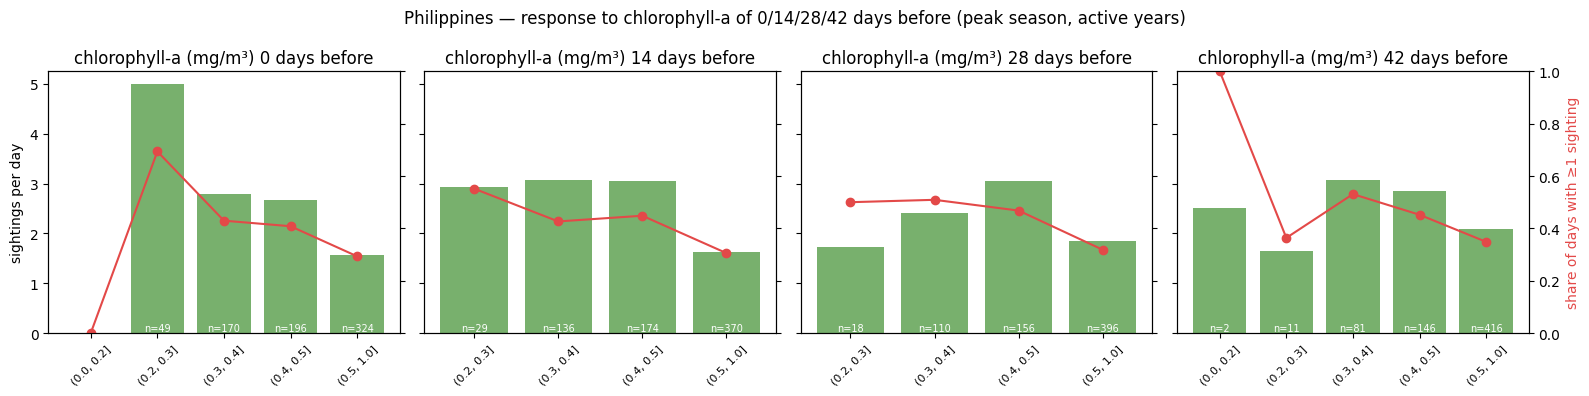

In [26]:
lagged_response(s)

*Reading:* At every lag the only stable feature is that the highest class (> 0.5 mg/m³) has the fewest sightings (1.6–1.9 per day) — but that class is mostly February–March, when chlorophyll is still high and the season has barely started, so it is the calendar again. The other classes are unordered and the low classes have very few days (2–29). No lagged effect of chlorophyll.

#### Year by year

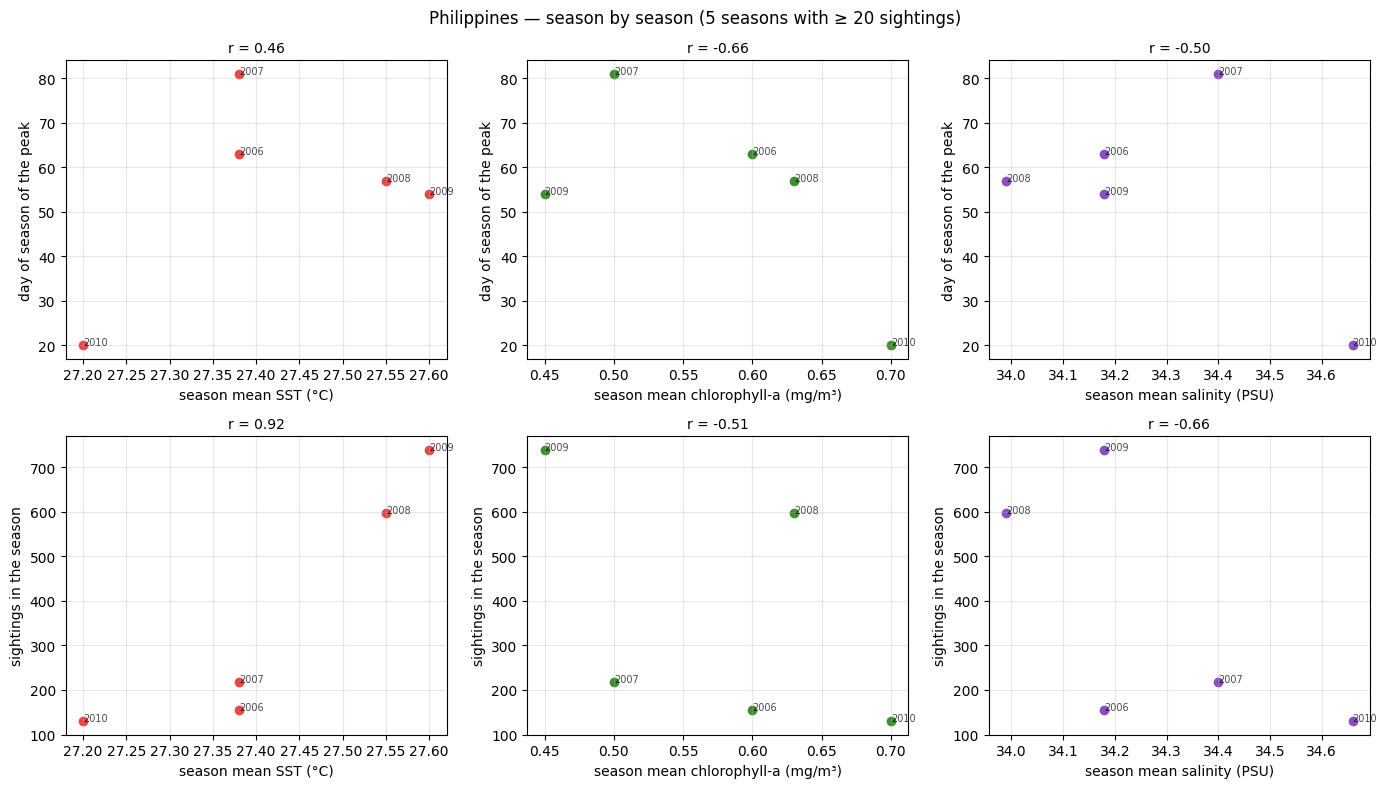

,season,sightings,peak_sday,sst,chl,sss
0,2006,155,63,27.38,0.60,34.18
1,2007,218,81,27.38,0.50,34.40
2,2008,597,57,27.55,0.63,33.99
3,2009,739,54,27.60,0.45,34.18
4,2010,130,20,27.20,0.70,34.66


In [27]:
season_by_year(s)
year_plots(s)


*Reading:* Only 5 seasons with enough data (2006–2010): correlations are not meaningful with so few points (one season can produce r = 0.9). The plots mainly show where the earlier patterns come from: the drop above 34.5 PSU in the salinity response curve is a single season (2010, 34.65 PSU, 130 sightings), and the apparent link between SST and total sightings is driven by 2008–2009, when the catalogue grew to 600–740 records. No conclusion about year-to-year effects in the Philippines.

### 4.3 Mozambique (Toho / Inhambane) — October to March

#### Context (climatology)

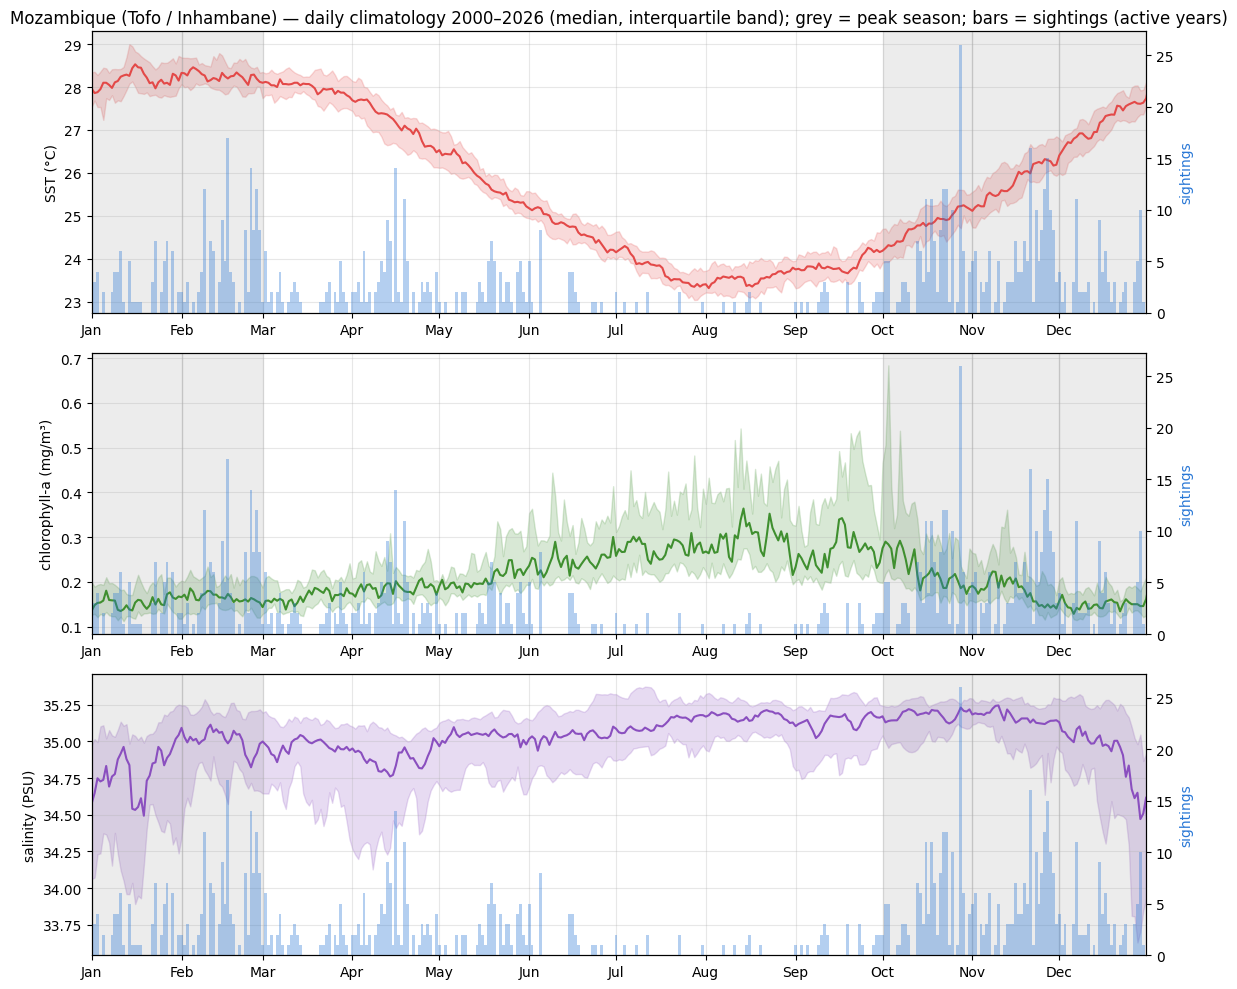

In [28]:
s = SITES[2]
climatology(s)

*Reading:*

**SST:** Like the Philippines and opposite to Ningaloo, sharks are seen while the SST is rising: the season starts in October at about 23.5 °C and ends in February at 28.5 °C, the annual maximum. Sightings peak in November–December (25–27 °C).

**Chlorophyll-a:** The annual maximum is in winter (July–October, 0.35 mg/m³). The season starts as chlorophyll falls and runs through the annual minimum (0.15 mg/m³ in December–February). This is the opposite of the Philippines, where chlorophyll peaks just before the season.

**SSS:** High and stable (~35.0–35.2 PSU) for most of the year, with a drop to ~34.5 in December–January during the rainy season, i.e. inside the season. The interquartile band is wide in those months, so year-to-year rainfall differences are large. Compared with the other sites, Tofo is saltier overall (35 vs 34.3 in the Philippines).

**Note:** Tofo also has many sightings outside the season (April, June), so the season is less sharp than at Ningaloo and in the Philippines.

#### Response curves — SST

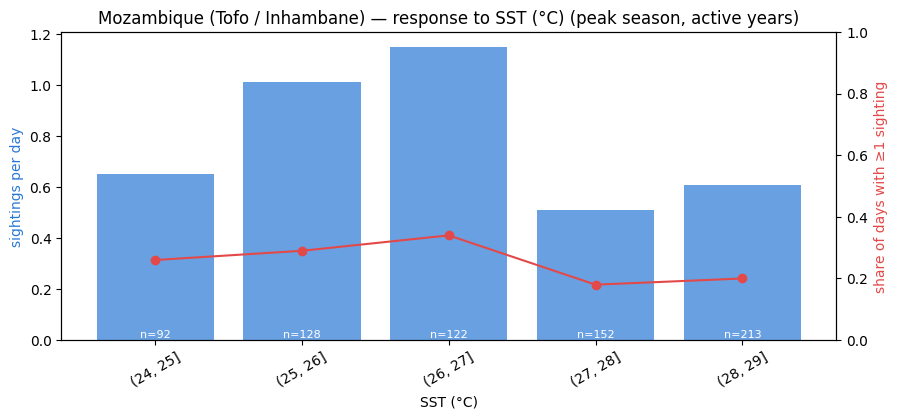

,n_days,sightings,days_with,per_day,p_sighting
cls,,,,,
"(24, 25]",92,60,24,0.65,0.26
"(25, 26]",128,129,37,1.01,0.29
"(26, 27]",122,140,41,1.15,0.34
"(27, 28]",152,77,27,0.51,0.18
"(28, 29]",213,129,42,0.61,0.20


In [29]:
response_curve(s, 'sst', [24, 25, 26, 27, 28, 29], 'SST (°C)')

*Reading:* Bell shape with a maximum at 26–27 °C (1.2 sightings/day, 34% of days), then a drop above 27 °C. 26–27 °C corresponds to Oct–Nov, the start of the season, so this may again be a calendar effect — to be checked with the relative response.

#### Response curves — chlorophyll-a

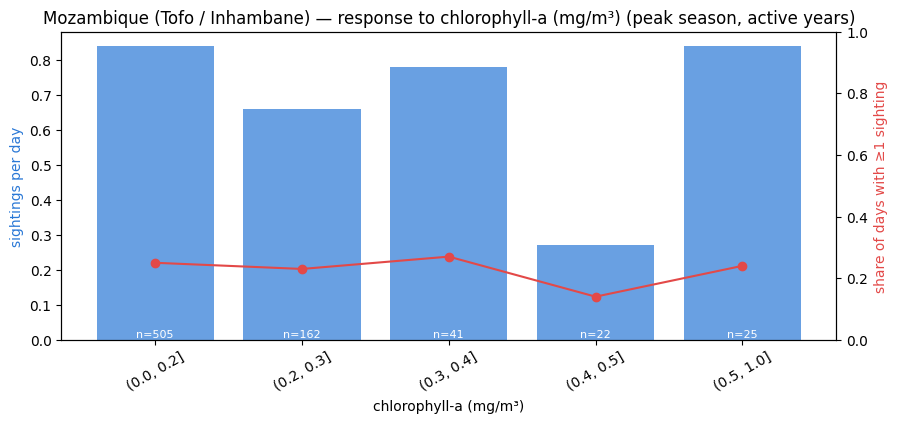

,n_days,sightings,days_with,per_day,p_sighting
cls,,,,,
"(0.0, 0.2]",505,423,127,0.84,0.25
"(0.2, 0.3]",162,107,38,0.66,0.23
"(0.3, 0.4]",41,32,11,0.78,0.27
"(0.4, 0.5]",22,6,3,0.27,0.14
"(0.5, 1.0]",25,21,6,0.84,0.24


In [30]:
response_curve(s, 'chl', [0, 0.2, 0.3, 0.4, 0.5, 1], 'chlorophyll-a (mg/m³)')

*Reading:* No pattern. 70% of season days have chlorophyll below 0.2 mg/m³; the higher classes have too few days (22–41) to read.

#### Response curves — salinity

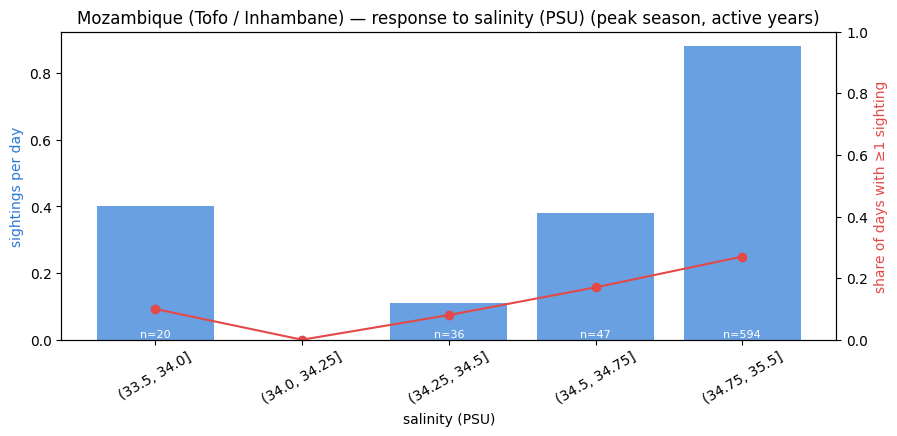

,n_days,sightings,days_with,per_day,p_sighting
cls,,,,,
"(33.5, 34.0]",20,8,2,0.40,0.10
"(34.0, 34.25]",18,0,0,0.00,0.00
"(34.25, 34.5]",36,4,3,0.11,0.08
"(34.5, 34.75]",47,18,8,0.38,0.17
"(34.75, 35.5]",594,524,163,0.88,0.27


In [31]:
response_curve(s, 'sss', [33.5, 34.0, 34.25, 34.5, 34.75, 35.5], 'salinity (PSU)')

*Reading:* 594 of 717 days fall in one class (34.75–35.5), so the curve is not informative. The few low-salinity days (rainy periods in Dec–Jan) have fewer sightings, which could be weather and boat effort rather than the sharks.

#### Anomaly response curves

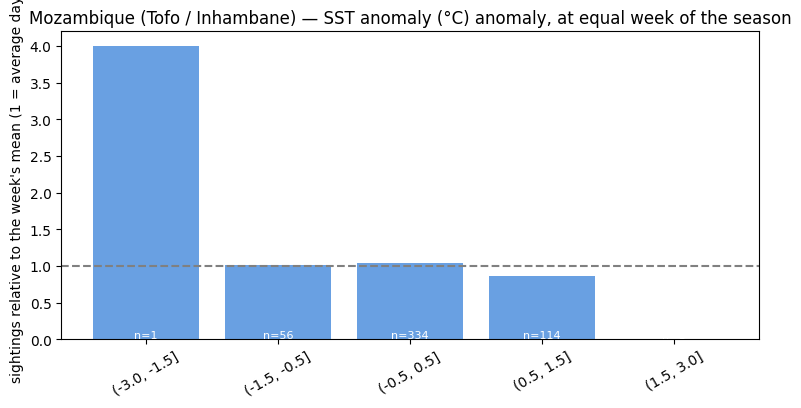

,n_days,relative
cls,,
"(-3.0, -1.5]",1,4.00
"(-1.5, -0.5]",56,1.01
"(-0.5, 0.5]",334,1.04
"(0.5, 1.5]",114,0.86
"(1.5, 3.0]",1,0.00


In [32]:
relative_response(s, "sst", [-3, -1.5, -0.5, 0.5, 1.5, 3],          "SST anomaly (°C)")

*Reading:* At equal week of the season the SST effect disappears: the two well-populated classes (−1.5 to +0.5 °C, n = 390) sit at 1.0, and warmer-than-normal days are only slightly lower (0.87, n = 114). The ***4.0 bar is a single day*** and should be ignored. The bell seen in the plain curve was therefore a calendar effect, as at the other two sites.

#### Lagged chlorophyll

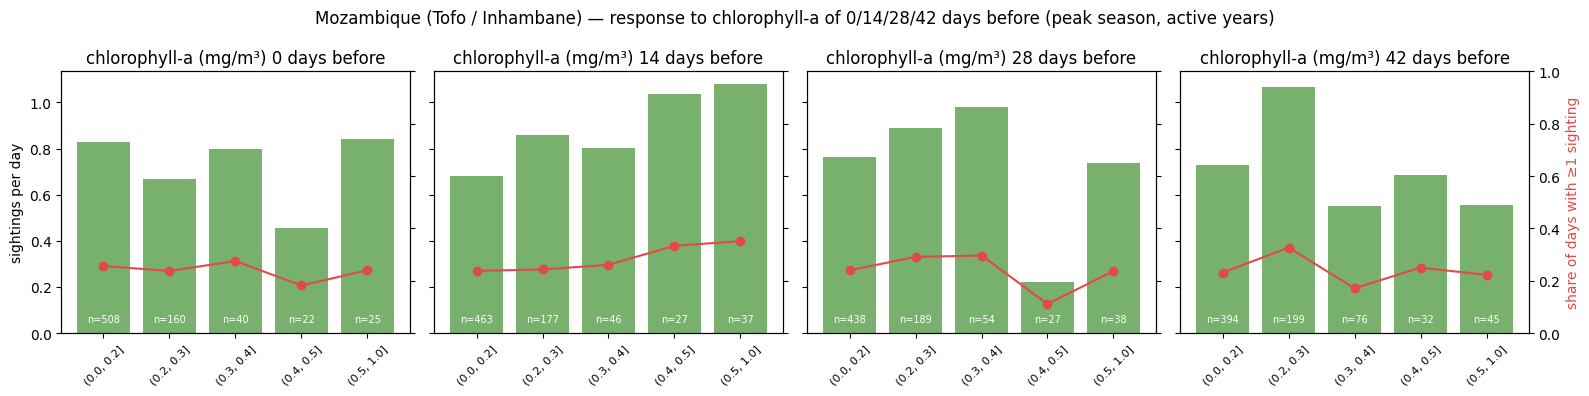

In [33]:
lagged_response(s)

*Reading:* No consistent pattern. The 14-day panel rises with chlorophyll (0.7 → 1.1 sightings/day) but the higher classes have 27–37 days only, and the 28- and 42-day panels do not confirm it. With 70% of days in the lowest class, the curve is driven by a few days.

#### Year by year

,season,sightings,peak_sday,sst,chl,sss
0,2005,229,55,26.96,0.21,34.68
1,2006,128,49,27.00,0.20,35.09
2,2007,55,149,26.88,0.19,34.96
3,2008,157,25,26.80,0.25,34.66
4,2009,23,144,26.78,0.19,34.94


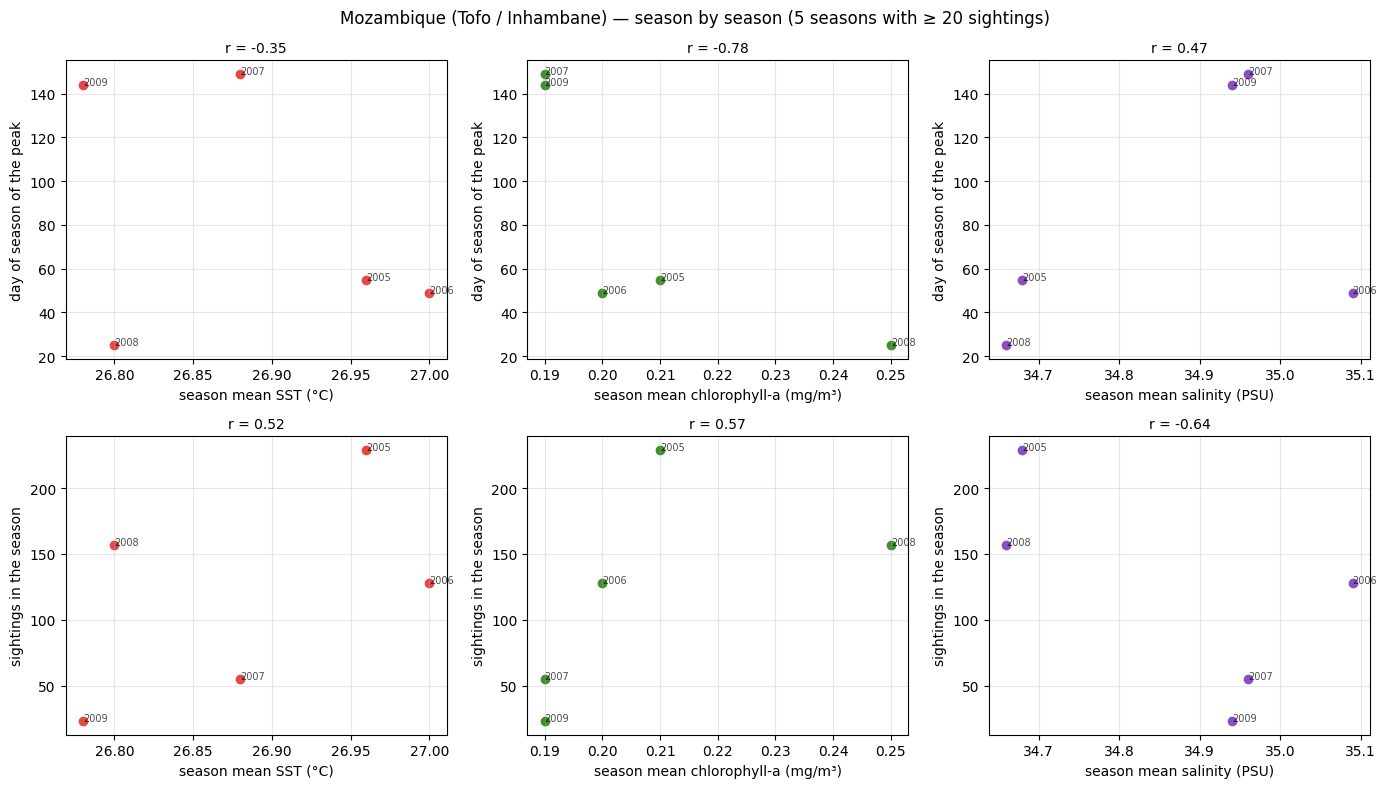

,season,sightings,peak_sday,sst,chl,sss
0,2005,229,55,26.96,0.21,34.68
1,2006,128,49,27.00,0.20,35.09
2,2007,55,149,26.88,0.19,34.96
3,2008,157,25,26.80,0.25,34.66
4,2009,23,144,26.78,0.19,34.94


In [34]:
tab = season_by_year(s)
display(tab)

year_plots(s)

*Reading:* Only 5 active seasons (2005–2009), so correlations are not meaningful. Peak timing splits into two groups: early peaks (day 25–55 = Nov, seasons 2005, 2006, 2008) and late peaks (day 145–150 = Feb, seasons 2007, 2009); the late-peak seasons are also the ones with the fewest sightings (25–55), so the "late peak" is probably the largest day in a thin season rather than a real shift. Season totals fall from 2005 to 2009, which reflects the data provider's activity, not the sharks.

## Step 5 — Comparison of the three sites

### 5.1 Summary table: site × variable → shape of the response curve, holds with anomalies?, useful lag?

## 5. Summary

| Site (season) | SST | Chlorophyll-a | Salinity | Lagged chl (14–42 d) | Season by season |
|---|---|---|---|---|---|
| **Ningaloo** (Apr–Jun, 9 seasons) | Plain curve: bell, max 27–28 °C. At equal week: flat (0.94–1.02) → calendar effect | Flat | Flat | No pattern | Peak timing r ≤ 0.10; totals follow catalogue growth |
| **Philippines** (Feb–May, 5 seasons) | Plain curve: bell (×10). At equal week: flat → calendar effect | Decreasing = calendar reversed; at equal week: flat | Bell from between-year differences (2010); at equal week: flat | No pattern | Too few seasons |
| **Mozambique – Tofo** (Oct–Feb, 5 seasons) | Plain curve: bell, max 26–27 °C. At equal week: flat (1.0; warm days 0.87) → calendar effect | Flat (70% of days < 0.2 mg/m³) | Not informative (83% of days in one class) | No consistent pattern | Too few seasons; late peaks = thin seasons |

*Season position on the annual cycle:*

| Site | SST | Chlorophyll-a | Salinity |
|---|---|---|---|
| Ningaloo | cooling limb (28.5 → 25 °C) | weak rise inside season | annual minimum |
| Philippines | warming limb (26 → 29.5 °C) | annual max just before season | annual maximum |
| Mozambique – Tofo | warming limb (23.5 → 28.5 °C) | annual max before season, min inside | high and stable, drop in Dec–Jan rains |

### 5.2 Conclusions



## Conclusions

1. **The three satellite variables describe the season, not the day.** At every site the plain response curves show a clear shape (a bell in SST), but the shape disappears once sightings are compared at equal week of the season. The curves were tracking the calendar, not the sharks.

2. **There is no shared environmental "trigger".** The seasons sit on opposite sides of the SST cycle (cooling at Ningaloo, warming in the Philippines and at Tofo), at the salinity minimum in one site and maximum in the others, and before or after the chlorophyll peak. No single value of SST, chlorophyll or salinity identifies whale-shark days across sites.

3. **Chlorophyll with a lag of 2–6 weeks adds nothing at daily scale.** No consistent pattern at any site.

4. **Season-to-season variation cannot be tested with these data.** Only Ningaloo has enough seasons (9), and even there peak timing shows no relation with SST, chlorophyll or salinity (|r| ≤ 0.10). Season totals follow the growth of the photo-ID catalogues, not the environment.

5. **Main limitation: observation effort.** Sightings come from tour boats and photo-ID catalogues, so "no sighting" often means "no boat went out" (weather, weekends, low season). This limits what any daily-scale analysis can see. A proper test needs effort data (number of trips per day) or a variable that acts on a different time scale — e.g. the sound-related parameter to be added next.